# PELABELAN SENTIMEN & WORD EMBEDDING — VERSI PERBAIKAN
# ======================================================
# Proyek  : Skripsi Ilmal Yakin Nurahman (224260028)
# File    : 2_Labeling_Embedding.ipynb
# Input   : dataset_mbg_preprocessed.csv
# Output  : dataset_mbg_final_for_training.csv
#           X_padded_sequences.npy, y_onehot_labels.npy
#           tokenizer.pkl, label_encoder.pkl
# ======================================================


# BAGIAN 0 — IMPORT DAN INSTALASI

In [1]:
# ============================================================
# BAGIAN 0 — IMPORT DAN INSTALASI
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import ast
import urllib.request
import os
import warnings
warnings.filterwarnings('ignore')

!pip install Sastrawi -q
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

print("✅ Semua library berhasil diimport")

✅ Semua library berhasil diimport


# BAGIAN 1 — LOAD DATA

In [2]:
# BAGIAN 1 — LOAD DATA (DIPERBAIKI)
from google.colab import drive
drive.mount('/content/drive')

DRIVE_FOLDER = '/content/drive/MyDrive/skripsi_mbg'

# PERBAIKAN: semua path didefinisikan dari DRIVE_FOLDER
INPUT_PATH     = f'{DRIVE_FOLDER}/data/processed/dataset_mbg_preprocessed.csv'
LEXICON_POS_PATH = f'{DRIVE_FOLDER}/lexicon/positive_words.tsv'
LEXICON_NEG_PATH = f'{DRIVE_FOLDER}/lexicon/negative_words.tsv'

OUT_LABELED_CSV = f'{DRIVE_FOLDER}/data/processed/dataset_mbg_labeled.csv'
OUT_FINAL_CSV   = f'{DRIVE_FOLDER}/data/processed/dataset_mbg_final_for_training.csv'
OUT_X_NPY       = f'{DRIVE_FOLDER}/data/embeddings/X_padded_sequences.npy'
OUT_Y_NPY       = f'{DRIVE_FOLDER}/data/embeddings/y_onehot_labels.npy'
OUT_TOKENIZER   = f'{DRIVE_FOLDER}/data/embeddings/tokenizer.pkl'
OUT_LABEL_ENC   = f'{DRIVE_FOLDER}/data/embeddings/label_encoder.pkl'
OUT_METADATA    = f'{DRIVE_FOLDER}/data/embeddings/embedding_metadata.json'
OUT_CW          = f'{DRIVE_FOLDER}/data/embeddings/class_weights.json'
OUT_FIG_LABEL   = f'{DRIVE_FOLDER}/figures/sentiment_labeling_analysis.png'
OUT_FIG_EMBED   = f'{DRIVE_FOLDER}/figures/word_embedding_analysis.png'

# Buat direktori jika belum ada
for path in [OUT_X_NPY, OUT_Y_NPY, OUT_TOKENIZER,
             OUT_LABEL_ENC, OUT_METADATA, OUT_FIG_LABEL]:
    os.makedirs(os.path.dirname(path), exist_ok=True)

def parse_tokens(tokens_str):
    """
    Mengubah string representasi list token menjadi list Python.
    Menangani kasus di mana input sudah berupa list.
    """
    if isinstance(tokens_str, list):
        return tokens_str
    try:
        return ast.literal_eval(tokens_str)
    except (ValueError, SyntaxError):
        return [] # Return empty list if parsing fails

# Load data
df = pd.read_csv(INPUT_PATH)
df['tokens'] = df['tokens'].apply(parse_tokens)

print(f"Total tweets dimuat: {len(df)}")  # harus 2301
print(f"Kolom: {df.columns.tolist()}")

# Verifikasi — pastikan bukan data lama
assert len(df) > 2000, f"❌ Data kemungkinan masih lama! ({len(df)} baris)"
print("✅ Verifikasi jumlah data: OK")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total tweets dimuat: 2301
Kolom: ['full_text', 'text_final', 'tokens']
✅ Verifikasi jumlah data: OK


In [3]:
# 1. Instalasi library pendeteksi bahasa (jika belum)
!pip install langdetect -q
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

def clean_relevance_and_lang(df):
    initial_count = len(df)

    # A. Filter Bahasa (Hanya ambil Bahasa Indonesia)
    # Filter bahasa ini sudah tepat dan terbukti membuang 50 noise
    def is_indonesian(text):
        try:
            return detect(text) == 'id'
        except:
            return False

    # Gunakan 'full_text' agar deteksi bahasa lebih akurat sebelum teks dipotong-potong
    df = df[df['full_text'].apply(is_indonesian)].copy()
    lang_removed = initial_count - len(df)

    # B. Filter Relevansi (Gunakan BLACKLIST, bukan Whitelist)
    # Masukkan kata-kata yang PASTI menandakan tweet itu OOT (Out of Topic) / Noise
    blacklist_noise = ['halalbihalal', 'giveaway', 'slot', 'judi', 'promo', 'diskon']
    pattern = '|'.join(blacklist_noise)

    # HAPUS tweet yang mengandung kata blacklist (menggunakan tanda ~ untuk negasi)
    df_filtered = df[~df['full_text'].str.contains(pattern, case=False, na=False)].copy()
    noise_removed = len(df) - len(df_filtered)

    df = df_filtered

    print(f"✅ Hapus bahasa asing: {lang_removed} baris")
    print(f"✅ Hapus noise (blacklist): {noise_removed} baris")
    print(f"✅ Total data bersih siap dilabeli: {len(df)} baris")

    return df

# Jalankan pembersihan
df = clean_relevance_and_lang(df)

✅ Hapus bahasa asing: 50 baris
✅ Hapus noise (blacklist): 6 baris
✅ Total data bersih siap dilabeli: 2245 baris


# BAGIAN 2 — DOWNLOAD DAN LOAD LEXICON InSet

In [4]:
# ============================================================
# BAGIAN 2 — DOWNLOAD DAN LOAD LEXICON InSet
# ============================================================

print("\n" + "=" * 70)
print("DOWNLOAD LEXICON SENTIMEN InSet")
print("=" * 70)

os.makedirs(os.path.dirname(LEXICON_POS_PATH), exist_ok=True)

URL_POS = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
URL_NEG = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

# Download jika belum ada
if not os.path.exists(LEXICON_POS_PATH):
    urllib.request.urlretrieve(URL_POS, LEXICON_POS_PATH)
    print("✅ Positive lexicon didownload")
else:
    print("✅ Positive lexicon sudah ada (skip download)")

if not os.path.exists(LEXICON_NEG_PATH):
    urllib.request.urlretrieve(URL_NEG, LEXICON_NEG_PATH)
    print("✅ Negative lexicon didownload")
else:
    print("✅ Negative lexicon sudah ada (skip download)")


def load_lexicon_with_weight(filepath, is_negative=False):
    """
    Load lexicon InSet dengan bobot skor sentimen.

    CATATAN PENTING tentang format InSet:
    - File positive.tsv: bobot sudah positif  (contoh: bagus\t3)
    - File negative.tsv: bobot juga POSITIF   (contoh: buruk\t3)
      → Kita perlu mengubah tanda menjadi negatif untuk file negatif
      → Caranya: kalikan -1 jika is_negative=True

    Args:
        filepath   (str) : Path ke file lexicon .tsv
        is_negative(bool): True jika ini file negative lexicon

    Returns:
        dict: {kata: bobot_skor}
              - untuk positif: bobot > 0
              - untuk negatif: bobot < 0 (sudah dibalik tandanya)
    """
    lexicon = {}
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t')
            word  = parts[0].lower().strip()
            if len(parts) >= 2:
                try:
                    score = float(parts[1])
                except ValueError:
                    score = 1.0
            else:
                score = 1.0

            # ← KUNCI PERBAIKAN:
            # Untuk negative lexicon, balik tanda menjadi negatif
            if is_negative:
                score = -abs(score)

            lexicon[word] = score
    return lexicon

# ← Perhatikan parameter is_negative yang ditambahkan
positive_lexicon = load_lexicon_with_weight(LEXICON_POS_PATH, is_negative=False)
negative_lexicon = load_lexicon_with_weight(LEXICON_NEG_PATH, is_negative=True)

print(f"\nStatistik Lexicon:")
print(f"  Total positive words : {len(positive_lexicon)}")
print(f"  Total negative words : {len(negative_lexicon)}")

# Verifikasi — sample skor harus negatif untuk lexicon negatif
sample_neg = list(negative_lexicon.items())[:5]
sample_pos = list(positive_lexicon.items())[:5]
print(f"\nVerifikasi sample positive (harus > 0):")
for w, s in sample_pos:
    print(f"  '{w}' : {s}")
print(f"\nVerifikasi sample negative (harus < 0):")
for w, s in sample_neg:
    print(f"  '{w}' : {s}")

# Stemming lexicon
stemmer = StemmerFactory().create_stemmer()
print("\n⏳ Stemming lexicon...")
positive_lexicon = {stemmer.stem(k): v for k, v in positive_lexicon.items()}
negative_lexicon = {stemmer.stem(k): v for k, v in negative_lexicon.items()}
print("✅ Stemming selesai")


DOWNLOAD LEXICON SENTIMEN InSet
✅ Positive lexicon sudah ada (skip download)
✅ Negative lexicon sudah ada (skip download)

Statistik Lexicon:
  Total positive words : 3608
  Total negative words : 6607

Verifikasi sample positive (harus > 0):
  'word' : 1.0
  'hai' : 3.0
  'merekam' : 2.0
  'ekstensif' : 3.0
  'paripurna' : 1.0

Verifikasi sample negative (harus < 0):
  'word' : -1.0
  'putus tali gantung' : -2.0
  'gelebah' : -2.0
  'gobar hati' : -2.0
  'tersentuh (perasaan)' : -1.0

⏳ Stemming lexicon...
✅ Stemming selesai


## BAGIAN 2B — KAMUS KONTEKSTUAL KHUSUS MBG

In [5]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   BAGIAN 2B — KAMUS KONTEKSTUAL MBG (DIPERLUAS)            ║
# ╚══════════════════════════════════════════════════════════════╝
#
# PERUBAHAN dari versi lama:
# - Tambah ~30 kata negatif baru yang sering muncul di data crawl
# - Tambah kata positif yang sering SALAH dihitung InSet
#   ke KATA_OVERRIDE_NETRAL (lihat Bagian 2C)

KAMUS_KONTEKSTUAL_MBG = {
    # Tambahan Kata Negatif Kuat & Slang X
    'ngawur': -4, 'kritik': -3, 'mengkritik': -3, 'ajng': -5, 'anjing': -5,
    'bego': -4, 'tolol': -5, 'bodoh': -4, 'elite': -2, 'elit': -2,

    # Kata Negatif Kuat (Tetap)
    'keracunan': -5, 'racun': -4, 'muntah': -4, 'diare': -4, 'mual': -4,
    'lemas': -3, 'sakit': -3, 'korban': -4, 'darurat': -3, 'dirawat': -4,
    'rumahsakit': -3, 'basi': -5, 'busuk': -5, 'kotor': -4, 'jorok': -4,
    'menjijikkan': -5, 'korupsi': -5, 'dikorupsi': -5, 'suap': -5, 'fiktif': -5,
    'markup': -4, 'pungut': -3, 'pungli': -4, 'gelap': -3, 'gagal': -4,
    'kacau': -4, 'berantakan': -4, 'terlambat': -3, 'telat': -3, 'berhenti': -3,
    'macet': -3, 'dihentikan': -4, 'dibatalkan': -4, 'tolak': -4, 'menolak': -4,
    'penolakan': -4, 'protes': -3, 'kecewa': -4, 'mengecewakan': -4, 'mubazir': -4,
    'sia': -3, 'percuma': -3, 'boros': -3, 'pemborosan': -3, 'pencitraan': -3,
    'gimik': -3, 'gimmick': -3, 'propaganda': -3, 'bohong': -4, 'tipu': -4,
    'dusta': -4, 'potong': -3, 'pangkas': -3, 'defisit': -3, 'utang': -2,
    'beban': -2, 'marah': -3, 'kesal': -3, 'jengkel': -3, 'kritis': -2,
    'buruk': -4, 'jelek': -3, 'parah': -4, 'hancur': -4, 'rusak': -3,
    'merugikan': -4, 'asbun': -4, 'zonk': -4, 'ricuh': -3, 'rusuh': -3,
    'sengsara': -4, 'hapus': -2, 'bubar': -3, 'batal': -3,

    # Kata Positif Kuat (Tetap)
    'dukung': +3, 'mendukung': +3, 'setuju': +3, 'bagus': +3, 'baik': +2,
    'mantap': +3, 'keren': +3, 'sehat': +3, 'tumbuh': +2, 'cerdas': +3,
    'produktif': +3, 'sukses': +4, 'berhasil': +4, 'lancar': +3, 'merata': +3,
    'adil': +3, 'bermanfaat': +4, 'membantu': +3, 'senang': +3, 'bangga': +3,
    'layak': +3, 'higienis': +3, 'jalan': +2, 'jelas': +2, 'tepat': +2, 'cukup': +2
}

KAMUS_KONTEKSTUAL_STEM = {}
for kata, skor in KAMUS_KONTEKSTUAL_MBG.items():
    kata_stem = stemmer.stem(kata)
    KAMUS_KONTEKSTUAL_STEM[kata_stem] = skor

print(f'✅ Kamus kontekstual MBG (diperluas): {len(KAMUS_KONTEKSTUAL_STEM)} kata')
neg_count = sum(1 for v in KAMUS_KONTEKSTUAL_STEM.values() if v < 0)
pos_count = sum(1 for v in KAMUS_KONTEKSTUAL_STEM.values() if v > 0)
print(f'   Kata negatif : {neg_count}')
print(f'   Kata positif : {pos_count}')

✅ Kamus kontekstual MBG (diperluas): 100 kata
   Kata negatif : 75
   Kata positif : 25


## BAGIAN 2C — DAFTAR NEGASI

In [6]:

# ╔══════════════════════════════════════════════════════════════╗
# ║   BAGIAN 2C — KATA NEGASI & OVERRIDE NETRAL (DIPERLUAS)    ║
# ╚══════════════════════════════════════════════════════════════╝
#
# PERUBAHAN UTAMA:
# Tambah KATA_OVERRIDE_NETRAL — kata yang oleh InSet dianggap
# positif tapi dalam konteks MBG sebenarnya netral/tidak bermakna
# sentimen. Ini PENYEBAB UTAMA skor tweet negatif jadi positif.

# Tambahkan stemming pada daftar negasi dan override
KATA_NEGASI = {stemmer.stem(w) for w in {
    'tidak', 'tak', 'bukan', 'jangan', 'belum', 'tanpa', 'kurang',
    'tiada', 'nihil', 'mustahil', 'ga', 'gak', 'ngga', 'nggak', 'enggak'
}}

KATA_OVERRIDE_NETRAL = {stemmer.stem(w) for w in {
    'makan', 'siang', 'nilai', 'pantau', 'awas', 'standar', 'menu',
    'dasar', 'titik', 'satu', 'layan', 'pasok', 'perintah', 'jalan',
    'jamin', 'tegas', 'dongkrak', 'sambang', 'konsolidasi', 'gratis',
    'bergizi', 'program', 'pemerintah', 'indonesia', 'sekolah', 'siswa'
}}
print(f'✅ KATA_NEGASI        : {len(KATA_NEGASI)} kata')
print(f'✅ KATA_OVERRIDE_NETRAL: {len(KATA_OVERRIDE_NETRAL)} kata (dari {20} versi lama)')

✅ KATA_NEGASI        : 15 kata
✅ KATA_OVERRIDE_NETRAL: 25 kata (dari 20 versi lama)


# BAGIAN 3 — FUNGSI PELABELAN SENTIMEN

In [7]:
# ==============================================================================
# BAGIAN 3 - FUNGSI PELABELAN (DIPERBAIKI - LOGIKA NEGASI FLAG)
# ==============================================================================

def hitung_skor_sentimen(tokens):
    skor_akhir = 0
    jumlah_pos = 0
    jumlah_neg = 0
    BOBOT_PENGALI = 2 # Kecilkan sedikit agar tidak terlalu dominan

    status_negasi = False
    jarak_dari_negasi = 0

    for token in tokens:
        if token in KATA_NEGASI:
            status_negasi = True
            jarak_dari_negasi = 0
            continue
        if token in KATA_OVERRIDE_NETRAL:
            continue
        if status_negasi:
            jarak_dari_negasi += 1
            if jarak_dari_negasi > 3: status_negasi = False

        skor_kata = 0
        is_sentimen = False

        # Kamus MBG (Contextual)
        if token in KAMUS_KONTEKSTUAL_STEM:
            skor_kata = KAMUS_KONTEKSTUAL_STEM[token] * BOBOT_PENGALI
            is_sentimen = True
        # InSet Positif (Filter Noise >= 3)
        elif token in positive_lexicon and positive_lexicon[token] >= 3:
            skor_kata = positive_lexicon[token]
            is_sentimen = True
        # InSet Negatif (Filter Noise <= -2)
        elif token in negative_lexicon and negative_lexicon[token] <= -2:
            skor_kata = negative_lexicon[token]
            is_sentimen = True

        if is_sentimen:
            if status_negasi:
                skor_kata = -skor_kata
                status_negasi = False
            skor_akhir += skor_kata
            if skor_kata > 0: jumlah_pos += 1
            elif skor_kata < 0: jumlah_neg += 1

    return skor_akhir, jumlah_pos, jumlah_neg

def tentukan_label(row):
    skor = row['sentiment_score']
    n_pos = row['jumlah_pos_kata']
    n_neg = row['jumlah_neg_kata']
    tokens = row['tokens'] if isinstance(row['tokens'], list) else []

    if (n_pos + n_neg) == 0:
        return 'NEUTRAL'

    # Deteksi Ekstrem Konteks MBG (Bypass skor jika ada kata super negatif)
    kata_negatif_kuat = {k for k, v in KAMUS_KONTEKSTUAL_STEM.items() if v <= -4}
    if any(t in kata_negatif_kuat for t in tokens) and n_neg > 0 and skor <= 3:
        return 'NEGATIVE'

    # Karena noise dari kata lemah InSet sudah difilter di hitung_skor_sentimen,
    # kita bisa menggunakan threshold natural yang ketat.
    if skor > 1:
        return 'POSITIVE'
    elif skor < -1:
        return 'NEGATIVE'
    else:
        # Skor -1, 0, atau 1 diklasifikasikan sebagai NEUTRAL (Sentimen lemah/seimbang)
        return 'NEUTRAL'

print('Fungsi hitung_skor_sentimen dan tentukan_label berhasil diperbaiki')

Fungsi hitung_skor_sentimen dan tentukan_label berhasil diperbaiki


# BAGIAN 4 — APLIKASIKAN PELABELAN

In [8]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   BAGIAN 4 — APLIKASIKAN PELABELAN                         ║
# ╚══════════════════════════════════════════════════════════════╝

print('\n' + '='*70)
print('PELABELAN SENTIMEN (LEXICON-BASED + BOBOT) — VERSI PERBAIKAN')
print('='*70)
print('⏳ Proses pelabelan...')

# Terapkan fungsi skor
hasil = df['tokens'].apply(hitung_skor_sentimen)
df['sentiment_score']   = hasil.apply(lambda x: x[0])
df['jumlah_pos_kata']   = hasil.apply(lambda x: x[1])
df['jumlah_neg_kata']   = hasil.apply(lambda x: x[2])

# Terapkan fungsi label — WAJIB axis=1
df['sentiment_label'] = df.apply(tentukan_label, axis=1)

print('✅ Pelabelan selesai!')

# ── Distribusi hasil ──────────────────────────────────────────
dist    = df['sentiment_label'].value_counts()
dist_pct = df['sentiment_label'].value_counts(normalize=True) * 100

print(f'\nDistribusi Sentimen:')
for label in ['NEGATIVE', 'NEUTRAL', 'POSITIVE']:
    count = dist.get(label, 0)
    pct   = dist_pct.get(label, 0)
    bar   = '█' * int(pct / 2)
    print(f'  {label:<10}: {count:>5,} tweet ({pct:5.1f}%)  {bar}')

# ── Cek threshold — beri peringatan jika NEGATIVE masih rendah ──
neg_pct = dist_pct.get('NEGATIVE', 0)
print(f'\n📊 Evaluasi distribusi:')
if neg_pct >= 20:
    print(f'  ✅ NEGATIVE {neg_pct:.1f}% — distribusi sudah representatif')
elif neg_pct >= 15:
    print(f'  ⚠️  NEGATIVE {neg_pct:.1f}% — lumayan, pantau performa model')
else:
    print(f'  ❌ NEGATIVE {neg_pct:.1f}% — masih rendah')
    print(f'     Coba turunkan threshold di tentukan_label:')
    print(f'     skor_norm < -0.1  →  skor_norm < -0.05')
    print(f'     n_neg >= 2        →  n_neg >= 1')

# ── Verifikasi manual 10 tweet acak ──────────────────────────
print(f'\nVerifikasi Manual (10 tweet acak):')
print('-'*70)
import random
random.seed(42)
idx_sample = random.sample(range(len(df)), min(10, len(df)))
for idx in idx_sample:
    row = df.iloc[idx]
    print(f"\nTeks  : {row['full_text'][:80]}...")
    print(f"Label : {row['sentiment_label']} "
          f"(skor: {row['sentiment_score']:.1f}, "
          f"pos: {row['jumlah_pos_kata']}, "
          f"neg: {row['jumlah_neg_kata']})")


PELABELAN SENTIMEN (LEXICON-BASED + BOBOT) — VERSI PERBAIKAN
⏳ Proses pelabelan...
✅ Pelabelan selesai!

Distribusi Sentimen:
  NEGATIVE  :   721 tweet ( 32.1%)  ████████████████
  NEUTRAL   :   168 tweet (  7.5%)  ███
  POSITIVE  : 1,356 tweet ( 60.4%)  ██████████████████████████████

📊 Evaluasi distribusi:
  ✅ NEGATIVE 32.1% — distribusi sudah representatif

Verifikasi Manual (10 tweet acak):
----------------------------------------------------------------------

Teks  : @ARSIPAJA Agak oot dikit yg kerjaan jadi pengawas mbg tuh selain yg sppi yg awal...
Label : NEGATIVE (skor: -4.0, pos: 3, neg: 4)

Teks  : Katanya sih Makan Bergizi Gratis tapi dapet susu bisa dihitung pake jari. Jangka...
Label : NEGATIVE (skor: -13.0, pos: 2, neg: 5)

Teks  : yah ga heran ada kasus keracunan di MBG wong kesehatannya aja masuk pendukung (i...
Label : POSITIVE (skor: 22.0, pos: 5, neg: 1)

Teks  : Sudahkah MBG tepat sasaran? Galih Sulistyaningra praktisi pendidikan dasar menil...
Label : POSITIVE (s

# BAGIAN 5 — CEK DAN TANGANI KETIDAKSEIMBANGAN DATA

In [9]:
# ============================================================
# BAGIAN 5 — CEK DAN TANGANI KETIDAKSEIMBANGAN DATA
# ============================================================

print("\n" + "=" * 70)
print("ANALISIS KESEIMBANGAN DATA")
print("=" * 70)

dist = df['sentiment_label'].value_counts()
min_class = dist.min()
max_class = dist.max()
ratio     = max_class / min_class

print(f"\nDistribusi kelas:")
for label, count in dist.items():
    print(f"  {label:<10}: {count}")
print(f"\nRasio kelas terbesar/terkecil: {ratio:.2f}")

if ratio > 1.5:
    print(f"\n⚠️  Ketidakseimbangan terdeteksi (rasio > 1.5)")
    print(f"   Akan ditangani dengan class_weight saat training model")
    print(f"   (Tidak perlu oversampling di sini — cukup di File 3 & 4)")
else:
    print(f"\n✅ Distribusi data cukup seimbang")

# Hitung class_weight untuk digunakan di training nanti
from sklearn.utils.class_weight import compute_class_weight

le_temp       = LabelEncoder()
y_temp        = le_temp.fit_transform(df['sentiment_label'])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_temp),
    y=y_temp
)
class_weight_dict = dict(enumerate(class_weights))

print(f"\nClass weights untuk training:")
for idx, label in enumerate(le_temp.classes_):
    print(f"  {label:<10} (class {idx}): {class_weights[idx]:.4f}")

# Simpan class_weight untuk digunakan di File 3 & 4
with open('/content/drive/MyDrive/skripsi_mbg/data/embeddings/class_weights.json', 'w') as f:
    json.dump(class_weight_dict, f, indent=2)
print("\n✅ class_weights.json tersimpan")

# Setelah pelabelan, cek distribusi
dist = df['sentiment_label'].value_counts()
rasio = dist.max() / dist.min()

print(f"\nDistribusi Sentimen:")
for label in ['NEGATIVE', 'NEUTRAL', 'POSITIVE']:
    count = dist.get(label, 0)
    pct   = count / len(df) * 100
    print(f"  {label:<10}: {count:>4} ({pct:.1f}%)")

print(f"\nRasio max/min: {rasio:.2f}")

# TAMBAHAN: warning jika NEGATIVE masih < 15%
neg_pct = dist.get('NEGATIVE', 0) / len(df) * 100
if neg_pct < 15:
    print(f"\n⚠️  WARNING: NEGATIVE hanya {neg_pct:.1f}%")
    print(f"   Pertimbangkan turunkan threshold negatif di fungsi tentukan_label")
    print(f"   Threshold saat ini: skor_norm < -0.5")
    print(f"   Coba ubah ke      : skor_norm < -0.3")
elif neg_pct < 20:
    print(f"\n⚠️  NEGATIVE {neg_pct:.1f}% — agak rendah, pantau performa model")
else:
    print(f"\n✅ Distribusi cukup representatif")


ANALISIS KESEIMBANGAN DATA

Distribusi kelas:
  POSITIVE  : 1356
  NEGATIVE  : 721
  NEUTRAL   : 168

Rasio kelas terbesar/terkecil: 8.07

⚠️  Ketidakseimbangan terdeteksi (rasio > 1.5)
   Akan ditangani dengan class_weight saat training model
   (Tidak perlu oversampling di sini — cukup di File 3 & 4)

Class weights untuk training:
  NEGATIVE   (class 0): 1.0379
  NEUTRAL    (class 1): 4.4544
  POSITIVE   (class 2): 0.5519

✅ class_weights.json tersimpan

Distribusi Sentimen:
  NEGATIVE  :  721 (32.1%)
  NEUTRAL   :  168 (7.5%)
  POSITIVE  : 1356 (60.4%)

Rasio max/min: 8.07

✅ Distribusi cukup representatif


# BAGIAN 6 — VISUALISASI HASIL PELABELAN (PERBAIKAN)

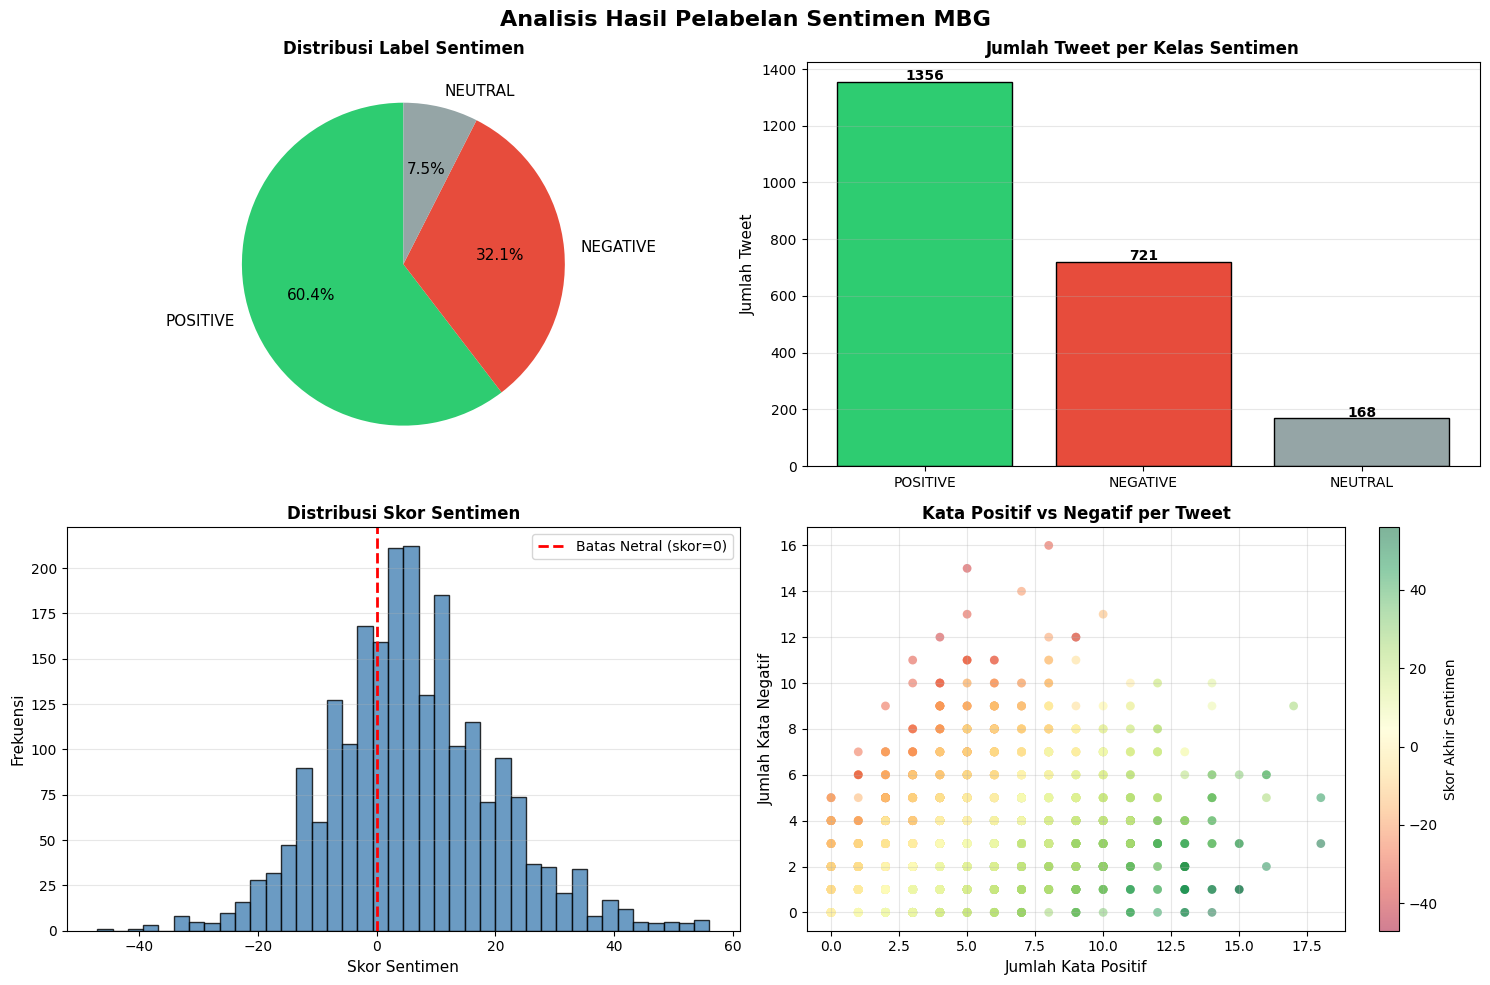

✅ Visualisasi tersimpan: /content/drive/MyDrive/skripsi_mbg/figures/sentiment_labeling_analysis.png


In [10]:
# ============================================================
# BAGIAN 6 — VISUALISASI HASIL PELABELAN (PERBAIKAN)
# ============================================================
# Jalankan SETELAH Bagian 5 (class_weights sudah terdefinisi)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Analisis Hasil Pelabelan Sentimen MBG', fontsize=16, fontweight='bold')

colors_map  = {'NEGATIVE': '#e74c3c', 'POSITIVE': '#2ecc71', 'NEUTRAL': '#95a5a6'}
dist_sorted = df['sentiment_label'].value_counts()

# Plot 1: Pie chart
colors_pie = [colors_map[l] for l in dist_sorted.index]
axes[0,0].pie(dist_sorted.values, labels=dist_sorted.index,
              autopct='%1.1f%%', colors=colors_pie,
              startangle=90, textprops={'fontsize': 11})
axes[0,0].set_title('Distribusi Label Sentimen', fontweight='bold')

# Plot 2: Bar chart
colors_bar = [colors_map[l] for l in dist_sorted.index]
bars = axes[0,1].bar(dist_sorted.index, dist_sorted.values,
                      color=colors_bar, edgecolor='black')
axes[0,1].set_ylabel('Jumlah Tweet', fontsize=11)
axes[0,1].set_title('Jumlah Tweet per Kelas Sentimen', fontweight='bold')
axes[0,1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, dist_sorted.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                    str(val), ha='center', fontweight='bold')

# Plot 3: Histogram skor sentimen
axes[1,0].hist(df['sentiment_score'], bins=40,
               color='steelblue', edgecolor='black', alpha=0.8)
axes[1,0].axvline(x=0, color='red', linestyle='--', linewidth=2,
                   label='Batas Netral (skor=0)')
axes[1,0].set_xlabel('Skor Sentimen', fontsize=11)
axes[1,0].set_ylabel('Frekuensi', fontsize=11)
axes[1,0].set_title('Distribusi Skor Sentimen', fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.3)

# Plot 4: Scatter plot — PERBAIKAN: gunakan nama kolom yang benar
scatter = axes[1,1].scatter(
    df['jumlah_pos_kata'],   # ← FIX: nama kolom yang benar
    df['jumlah_neg_kata'],   # ← FIX: nama kolom yang benar
    c=df['sentiment_score'], cmap='RdYlGn',
    alpha=0.5, s=40, edgecolor='none'
)
axes[1,1].set_xlabel('Jumlah Kata Positif', fontsize=11)
axes[1,1].set_ylabel('Jumlah Kata Negatif', fontsize=11)
axes[1,1].set_title('Kata Positif vs Negatif per Tweet', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1,1], label='Skor Akhir Sentimen')

plt.tight_layout()
plt.savefig(OUT_FIG_LABEL, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Visualisasi tersimpan: {OUT_FIG_LABEL}")

# BAGIAN 7 — SIMPAN DATASET BERLABEL

In [11]:
# ============================================================
# BAGIAN 7 — SIMPAN DATASET BERLABEL
# PERBAIKAN: simpan SEBELUM embedding agar konsisten
# ============================================================

# ⚠️ PENTING: df_labeled harus dibuat dari df yang sudah
# dilabeli di Bagian 4 — jangan load ulang dari CSV
df_labeled = df[[
    'full_text', 'text_final', 'tokens',
    'jumlah_pos_kata', 'jumlah_neg_kata',
    'sentiment_score', 'sentiment_label'
]].copy()

# Verifikasi distribusi SEBELUM simpan
print('Verifikasi distribusi df_labeled:')
print(df_labeled['sentiment_label'].value_counts())

df_labeled.to_csv(OUT_LABELED_CSV, index=False, encoding='utf-8')
print(f'\n✅ Dataset labeled tersimpan: {OUT_LABELED_CSV}')
print(f'   Total: {len(df_labeled)} baris')
print(f'   Kolom: {df_labeled.columns.tolist()}')

# ⚠️ CEK KONSISTENSI — angka ini harus SAMA dengan output Bagian 4
print(f'\nCek konsistensi:')
print(f'  df (Bagian 4) NEGATIVE : {(df["sentiment_label"]=="NEGATIVE").sum()}')
print(f'  df_labeled    NEGATIVE : {(df_labeled["sentiment_label"]=="NEGATIVE").sum()}')
print(f'  → Harus sama persis!')

Verifikasi distribusi df_labeled:
sentiment_label
POSITIVE    1356
NEGATIVE     721
NEUTRAL      168
Name: count, dtype: int64

✅ Dataset labeled tersimpan: /content/drive/MyDrive/skripsi_mbg/data/processed/dataset_mbg_labeled.csv
   Total: 2245 baris
   Kolom: ['full_text', 'text_final', 'tokens', 'jumlah_pos_kata', 'jumlah_neg_kata', 'sentiment_score', 'sentiment_label']

Cek konsistensi:
  df (Bagian 4) NEGATIVE : 721
  df_labeled    NEGATIVE : 721
  → Harus sama persis!


# BAGIAN 8 — WORD EMBEDDING

In [12]:
# ============================================================
# BAGIAN 8 — WORD EMBEDDING
# ============================================================

print("\n" + "=" * 70)
print("WORD EMBEDDING")
print("=" * 70)

# PERBAIKAN: sesuaikan dengan statistik preprocessing terbaru
# Unique token aktual : 6,588
# Max token aktual    : 42
# Median token        : 19

VOCAB_SIZE    = 7000   # ← PERBAIKAN: naik dari 5000, cover 6588 unique token
MAX_LENGTH    = 50     # ← tetap, karena max 42 < 50, tidak ada truncation
EMBEDDING_DIM = 128    # ← tetap
OOV_TOKEN     = "<OOV>"

print(f"Parameter Word Embedding:")
print(f"  VOCAB_SIZE    : {VOCAB_SIZE} (unique token aktual: 6588)")
print(f"  MAX_LENGTH    : {MAX_LENGTH} (max token aktual: 42, median: 19)")
print(f"  EMBEDDING_DIM : {EMBEDDING_DIM}")


WORD EMBEDDING
Parameter Word Embedding:
  VOCAB_SIZE    : 7000 (unique token aktual: 6588)
  MAX_LENGTH    : 50 (max token aktual: 42, median: 19)
  EMBEDDING_DIM : 128


## BAGIAN 8.1 — FIT TOKENIZER

In [13]:
# ============================================================
# BAGIAN 8.1 — FIT TOKENIZER
# ============================================================

print(f"\n⏳ Membuat dan melatih tokenizer...")

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(df_labeled['text_final'].values)

print(f"✅ Tokenizer selesai")
print(f"   Ukuran word_index  : {len(tokenizer.word_index)}")
print(f"   VOCAB_SIZE aktif   : {VOCAB_SIZE}")

print(f"\nSample Word Index (15 kata teratas):")
for word, idx in list(tokenizer.word_index.items())[:15]:
    print(f"   '{word}' → {idx}")


⏳ Membuat dan melatih tokenizer...
✅ Tokenizer selesai
   Ukuran word_index  : 6321
   VOCAB_SIZE aktif   : 7000

Sample Word Index (15 kata teratas):
   '<OOV>' → 1
   'makan' → 2
   'anak' → 3
   'keracunan' → 4
   'sekolah' → 5
   'jadi' → 6
   'indonesia' → 7
   'banyak' → 8
   'siswa' → 9
   'buat' → 10
   'sehat' → 11
   'bukan' → 12
   'lebih' → 13
   'prabowo' → 14
   'anggaran' → 15


## BAGIAN 8.2 — KONVERSI KE SEQUENCE DAN PADDING

In [14]:
# ============================================================
# BAGIAN 8.2 — KONVERSI KE SEQUENCE DAN PADDING
# ============================================================

print(f"\n⏳ Konversi teks ke sequence of integers...")
sequences = tokenizer.texts_to_sequences(df_labeled['text_final'].values)
print(f"✅ Konversi selesai")

# Statistik panjang sequence
original_lengths = [len(s) for s in sequences]
pct_truncated    = sum(1 for l in original_lengths if l > MAX_LENGTH)

print(f"\nStatistik Panjang Sequence (sebelum padding):")
print(f"   Min    : {min(original_lengths)}")
print(f"   Max    : {max(original_lengths)}")
print(f"   Mean   : {np.mean(original_lengths):.1f}")
print(f"   Median : {np.median(original_lengths):.1f}")
print(f"   Tweet > MAX_LENGTH ({MAX_LENGTH}) : {pct_truncated} "
      f"({pct_truncated/len(sequences)*100:.1f}%)")

# Padding
print(f"\n⏳ Melakukan padding (MAX_LENGTH={MAX_LENGTH})...")
padded_sequences = pad_sequences(
    sequences,
    maxlen=MAX_LENGTH,
    padding='post',    # padding di akhir sequence
    truncating='post'  # potong di akhir jika > MAX_LENGTH
)
print(f"✅ Padding selesai")
print(f"   Shape X : {padded_sequences.shape}")
print(f"             (jumlah_tweet × MAX_LENGTH)")


⏳ Konversi teks ke sequence of integers...
✅ Konversi selesai

Statistik Panjang Sequence (sebelum padding):
   Min    : 4
   Max    : 42
   Mean   : 18.9
   Median : 19.0
   Tweet > MAX_LENGTH (50) : 0 (0.0%)

⏳ Melakukan padding (MAX_LENGTH=50)...
✅ Padding selesai
   Shape X : (2245, 50)
             (jumlah_tweet × MAX_LENGTH)


## BAGIAN 8.3 — ENCODE LABEL KE ONE-HOT

In [15]:

# ============================================================
# BAGIAN 8.3 — ENCODE LABEL KE ONE-HOT
# ============================================================

print(f"\n⏳ Encoding label sentimen...")

le        = LabelEncoder()
y_encoded = le.fit_transform(df_labeled['sentiment_label'].values)
y_onehot  = to_categorical(y_encoded, num_classes=len(le.classes_))

print(f"✅ Label encoding selesai")
print(f"\nMapping label:")
for idx, label in enumerate(le.classes_):
    count = (y_encoded == idx).sum()
    print(f"   {label:<10} → {idx}  ({count} tweet)")

print(f"\nShape data untuk training:")
print(f"   X shape : {padded_sequences.shape}")
print(f"   y shape : {y_onehot.shape}")

print(f"\nSample (3 tweet pertama):")
for i in range(3):
    label = le.classes_[np.argmax(y_onehot[i])]
    print(f"   Tweet {i+1}: y={y_onehot[i]} → {label}")



⏳ Encoding label sentimen...
✅ Label encoding selesai

Mapping label:
   NEGATIVE   → 0  (721 tweet)
   NEUTRAL    → 1  (168 tweet)
   POSITIVE   → 2  (1356 tweet)

Shape data untuk training:
   X shape : (2245, 50)
   y shape : (2245, 3)

Sample (3 tweet pertama):
   Tweet 1: y=[0. 0. 1.] → POSITIVE
   Tweet 2: y=[0. 0. 1.] → POSITIVE
   Tweet 3: y=[0. 0. 1.] → POSITIVE


# BAGIAN 9 — VISUALISASI WORD EMBEDDING (PERBAIKAN)

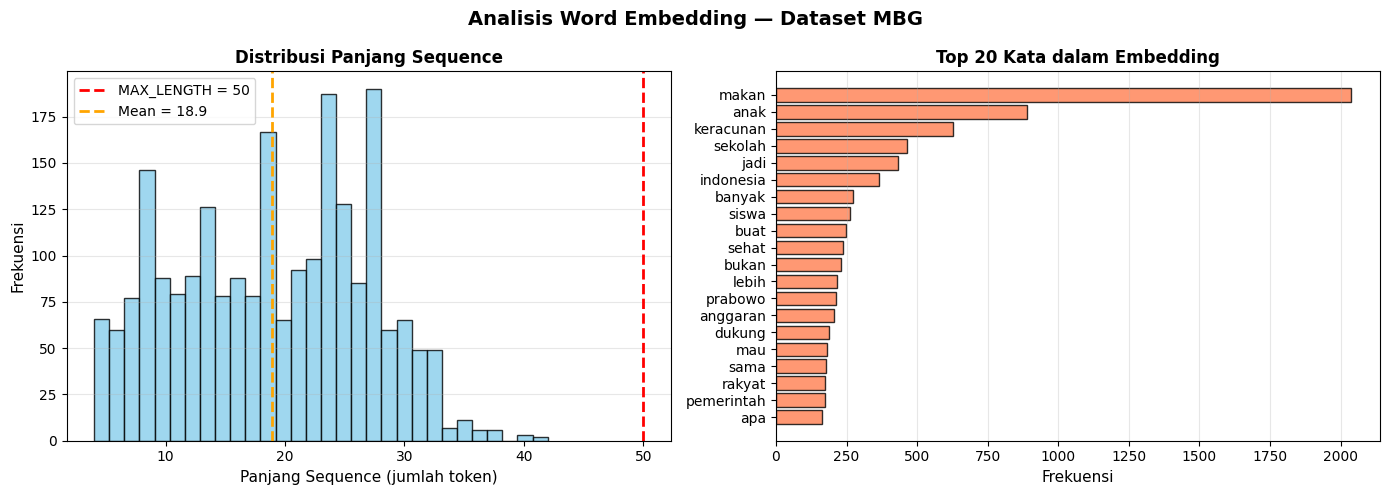

✅ Visualisasi tersimpan: /content/drive/MyDrive/skripsi_mbg/figures/word_embedding_analysis.png


In [16]:
# ============================================================
# BAGIAN 9 — VISUALISASI WORD EMBEDDING (PERBAIKAN)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Word Embedding — Dataset MBG', fontsize=14, fontweight='bold')

# Plot 1: Distribusi panjang sequence (tidak berubah)
axes[0].hist(original_lengths, bins=30, color='skyblue',
             edgecolor='black', alpha=0.8)
axes[0].axvline(x=MAX_LENGTH, color='red', linestyle='--', linewidth=2,
                label=f'MAX_LENGTH = {MAX_LENGTH}')
axes[0].axvline(x=np.mean(original_lengths), color='orange',
                linestyle='--', linewidth=2,
                label=f'Mean = {np.mean(original_lengths):.1f}')
axes[0].set_xlabel('Panjang Sequence (jumlah token)', fontsize=11)
axes[0].set_ylabel('Frekuensi', fontsize=11)
axes[0].set_title('Distribusi Panjang Sequence', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Top 20 kata — PERBAIKAN: reverse index untuk efisiensi O(1)
idx_to_word = {v: k for k, v in tokenizer.word_index.items()}  # ← FIX

word_freq = {}
for seq in sequences:
    for word_id in seq:
        if word_id <= 1:  # skip padding (0) dan OOV token (1)
            continue
        word = idx_to_word.get(word_id)
        if word:
            word_freq[word] = word_freq.get(word, 0) + 1

top20 = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:20]
words_top, freqs_top = zip(*top20)

axes[1].barh(words_top, freqs_top, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Frekuensi', fontsize=11)
axes[1].set_title('Top 20 Kata dalam Embedding', fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_FIG_EMBED, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Visualisasi tersimpan: {OUT_FIG_EMBED}")

In [17]:
# ============================================================
# BAGIAN 10 — SIMPAN SEMUA FILE
# ============================================================

print("\n" + "=" * 70)
print("MENYIMPAN SEMUA FILE")
print("=" * 70)

# X dan y
np.save(OUT_X_NPY, padded_sequences)
print(f"✅ X_padded_sequences.npy  → shape {padded_sequences.shape}")

np.save(OUT_Y_NPY, y_onehot)
print(f"✅ y_onehot_labels.npy     → shape {y_onehot.shape}")

# Tokenizer
with open(OUT_TOKENIZER, 'wb') as f:
    pickle.dump(tokenizer, f)
print(f"✅ tokenizer.pkl           → vocab size: {len(tokenizer.word_index)}")

# Label encoder
with open(OUT_LABEL_ENC, 'wb') as f:
    pickle.dump(le, f)
print(f"✅ label_encoder.pkl       → classes: {le.classes_.tolist()}")

# Dataset final
df_final                  = df_labeled.copy()
df_final['y_encoded']     = y_encoded
df_final.to_csv(OUT_FINAL_CSV, index=False, encoding='utf-8')
print(f"✅ dataset_mbg_final_for_training.csv → {len(df_final)} baris")

# Metadata
metadata = {
    'VOCAB_SIZE'          : VOCAB_SIZE,
    'MAX_LENGTH'          : MAX_LENGTH,
    'EMBEDDING_DIM'       : EMBEDDING_DIM,
    'OOV_TOKEN'           : OOV_TOKEN,
    'NUM_CLASSES'         : int(len(le.classes_)),
    'CLASS_LABELS'        : le.classes_.tolist(),
    'TOTAL_SAMPLES'       : int(len(df_final)),
    'X_SHAPE'             : list(padded_sequences.shape),
    'Y_SHAPE'             : list(y_onehot.shape),
    'TOKENIZER_VOCAB_SIZE': int(len(tokenizer.word_index)),
    'CLASS_WEIGHT'        : class_weight_dict,
    'DISTRIBUSI_SENTIMEN' : df['sentiment_label'].value_counts().to_dict(),
}
with open(OUT_METADATA, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"✅ embedding_metadata.json → berisi parameter + class_weight")



MENYIMPAN SEMUA FILE
✅ X_padded_sequences.npy  → shape (2245, 50)
✅ y_onehot_labels.npy     → shape (2245, 3)
✅ tokenizer.pkl           → vocab size: 6321
✅ label_encoder.pkl       → classes: ['NEGATIVE', 'NEUTRAL', 'POSITIVE']
✅ dataset_mbg_final_for_training.csv → 2245 baris
✅ embedding_metadata.json → berisi parameter + class_weight


# BAGIAN 11 — SUMMARY FINAL

In [18]:
# ============================================================
# BAGIAN 11 — SUMMARY FINAL
# ============================================================

print("\n" + "=" * 70)
print("SUMMARY PELABELAN SENTIMEN & WORD EMBEDDING")
print("=" * 70)

summary = pd.DataFrame({
    'Tahap': [
        '1. Data Input',
        '2. Setelah Labeling',
        '3. Setelah Embedding',
        '4. Final for Training'
    ],
    'Jumlah Sample': [
        len(df_labeled), len(df_labeled),
        len(padded_sequences), len(df_final)
    ],
    'Format': [
        'CSV (teks bersih)',
        'CSV + label sentimen',
        'Numpy array (integer)',
        'CSV + NPY arrays'
    ],
    'Shape / Info': [
        f"({len(df_labeled)}, 3 kolom)",
        f"({len(df_labeled)}, 7 kolom)",
        f"X: {padded_sequences.shape}",
        f"X: {padded_sequences.shape}, y: {y_onehot.shape}"
    ]
})
print(summary.to_string(index=False))

print(f"\nDistribusi Sentimen Final:")
for label in ['NEGATIVE', 'NEUTRAL', 'POSITIVE']:
    count = (df_final['sentiment_label'] == label).sum()
    pct   = count / len(df_final) * 100
    bar   = '█' * int(pct / 2)
    print(f"  {label:<10}: {count:>4} ({pct:>5.1f}%) {bar}")

print(f"\nFile tersimpan di Google Drive:")
files = [
    ('data/processed/', 'dataset_mbg_labeled.csv'),
    ('data/processed/', 'dataset_mbg_final_for_training.csv'),
    ('data/embeddings/', 'X_padded_sequences.npy'),
    ('data/embeddings/', 'y_onehot_labels.npy'),
    ('data/embeddings/', 'tokenizer.pkl'),
    ('data/embeddings/', 'label_encoder.pkl'),
    ('data/embeddings/', 'class_weights.json'),
    ('data/embeddings/', 'embedding_metadata.json'),
    ('figures/', 'sentiment_labeling_analysis.png'),
    ('figures/', 'word_embedding_analysis.png'),
]
for folder, fname in files:
    print(f"  ✅ skripsi_mbg/{folder}{fname}")

print("\n" + "=" * 70)
print("✅ PELABELAN & WORD EMBEDDING SELESAI!")
print("=" * 70)


SUMMARY PELABELAN SENTIMEN & WORD EMBEDDING
                Tahap  Jumlah Sample                Format                Shape / Info
        1. Data Input           2245     CSV (teks bersih)             (2245, 3 kolom)
  2. Setelah Labeling           2245  CSV + label sentimen             (2245, 7 kolom)
 3. Setelah Embedding           2245 Numpy array (integer)               X: (2245, 50)
4. Final for Training           2245      CSV + NPY arrays X: (2245, 50), y: (2245, 3)

Distribusi Sentimen Final:
  NEGATIVE  :  721 ( 32.1%) ████████████████
  NEUTRAL   :  168 (  7.5%) ███
  POSITIVE  : 1356 ( 60.4%) ██████████████████████████████

File tersimpan di Google Drive:
  ✅ skripsi_mbg/data/processed/dataset_mbg_labeled.csv
  ✅ skripsi_mbg/data/processed/dataset_mbg_final_for_training.csv
  ✅ skripsi_mbg/data/embeddings/X_padded_sequences.npy
  ✅ skripsi_mbg/data/embeddings/y_onehot_labels.npy
  ✅ skripsi_mbg/data/embeddings/tokenizer.pkl
  ✅ skripsi_mbg/data/embeddings/label_encoder.pkl